                                           Exploratory Data Analysis on Diwali Sales Dataset

In [5]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()   # improves plot style

In [6]:
# LOAD DATASET

# Loading the 'Diwali Sales Data' CSV file Dataset with unicode escape encoding

df = pd.read_csv(r"C:\Users\omhun\OneDrive\Documents\Diwali Sales Data.csv", encoding='unicode_escape')

In [7]:
df.head()   # views top 5 rows of data

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [8]:
df.shape    # checks shape (No. of rows, No. of columns)

(11251, 15)

In [9]:
df.columns  # checks column names

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

In [10]:
df.info()   # checks data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [11]:
df.isnull().sum()   # checks null values

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [12]:
# DATA CLEANING

# Remove unnecessary columns

df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [13]:
# Remove null values

df.dropna(inplace=True)

In [14]:
# Remove duplicates

df.drop_duplicates(inplace=True)

In [15]:
# Rename columns

df.rename(columns={'Marital_Status':'MaritalStatus'}, inplace=True)

In [16]:
# DATA PREPROCESSING

# Convert Amount to numeric

df['Amount'] = df['Amount'].astype(int)

df['Amount'].dtype

dtype('int64')

In [17]:
# Handle outliers

df = df[df['Amount'] > 0]

In [18]:
# Check Cleaned Dataset

df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,MaritalStatus,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


In [19]:
# Export Cleaned Dataset

df.to_csv("diwali_cleaned.csv", index=False)

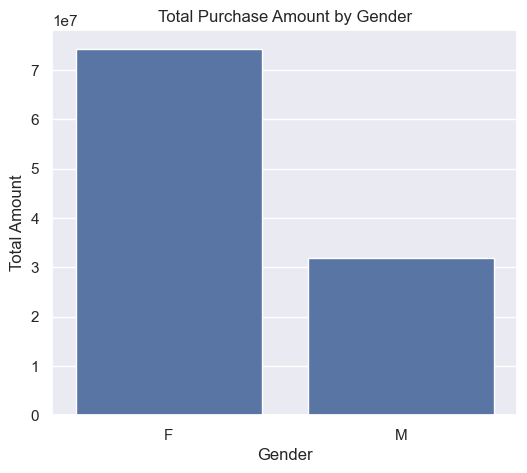

In [20]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Visualization 1 : Gender vs Total Purchase

plt.figure(figsize=(6,5))
gender_sales = df.groupby('Gender')['Amount'].sum()
sns.barplot(x=gender_sales.index, y=gender_sales.values)

plt.title("Total Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.show()

# Insight 1 : Females spent ₹7.43 Crore 
# Insight 2 : Males spent ₹3.18 Crore
# Insight 3 : Females spend more than twice as much as males
# Conclusion : Females are the primary buyers during Diwali.

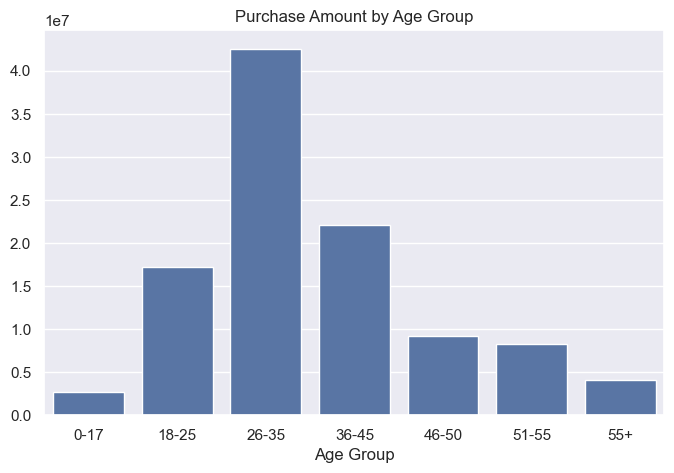

In [21]:
# Visualization 2 : Age Group vs Purchase Amount

plt.figure(figsize=(8,5))
age_sales = df.groupby('Age Group')['Amount'].sum()
sns.barplot(x=age_sales.index, y=age_sales.values)

plt.title("Purchase Amount by Age Group")
plt.show()

# Insight 1 : Age group 26–35 spent the most (₹4.25 Crore)
# Insight 2 : Followed by 36–45 age group
# Conclusion : Working professionals are the biggest buyers.

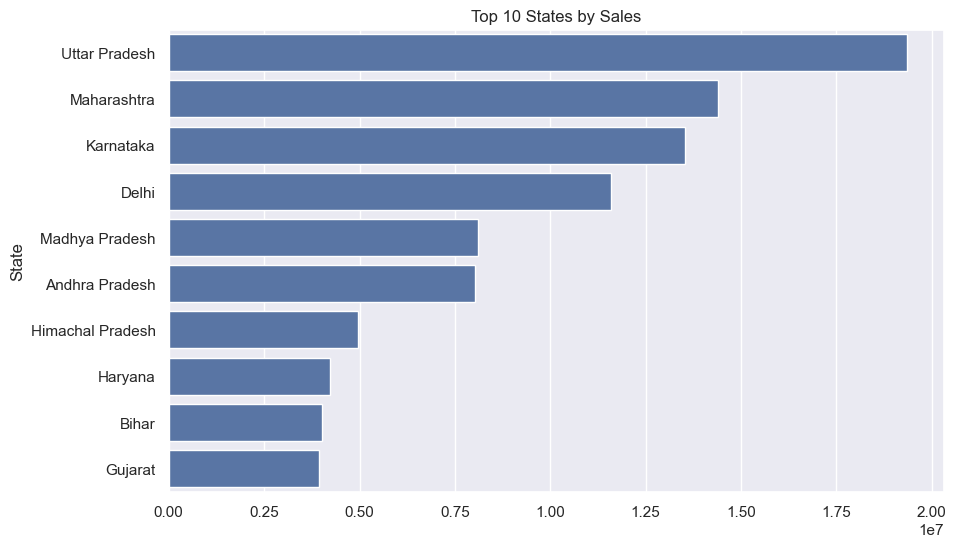

In [22]:
# Visualization 3 : Top 10 States by Sales

plt.figure(figsize=(10,6))
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Top 10 States by Sales")
plt.show()

# Insights : Top states: 1) Uttar Pradesh (Highest) 2) Maharashtra 3) Karnataka 4) Delhi
# Conclusion : North and Central India dominate sales.

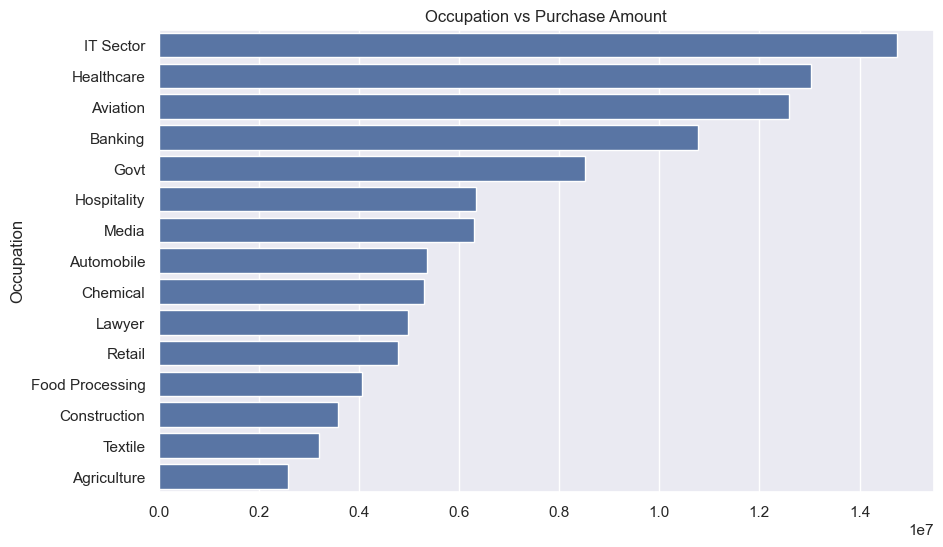

In [23]:
# Visualization 4 : Occupation vs Purchase

plt.figure(figsize=(10,6))
occ_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)

sns.barplot(x=occ_sales.values, y=occ_sales.index)
plt.title("Occupation vs Purchase Amount")
plt.show()

# Insights : Top occupations : 1) IT Sector (Highest) 2) Healthcare 3) Aviation 4) Banking
# Conclusion : High-income professionals spend more.

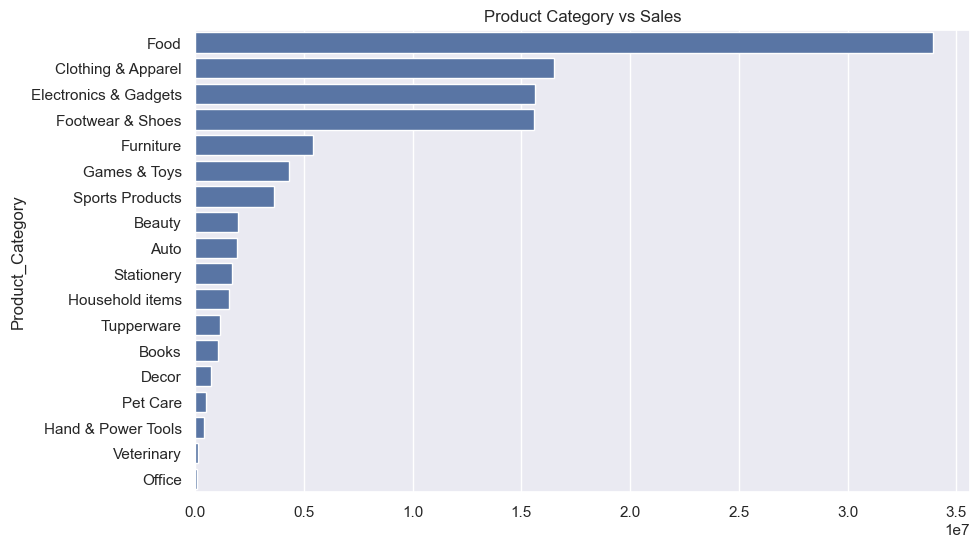

In [24]:
# Visualization 5 : Product Category Popularity

plt.figure(figsize=(10,6))
prod_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)

sns.barplot(x=prod_sales.values, y=prod_sales.index)
plt.title("Product Category vs Sales")
plt.show()

# Insights : Top categories : 1) Food (Highest) 2) Clothing & Apparel 3) Electronics 4) Footwear
# Conclusion : Food and clothing are most popular during Diwali.

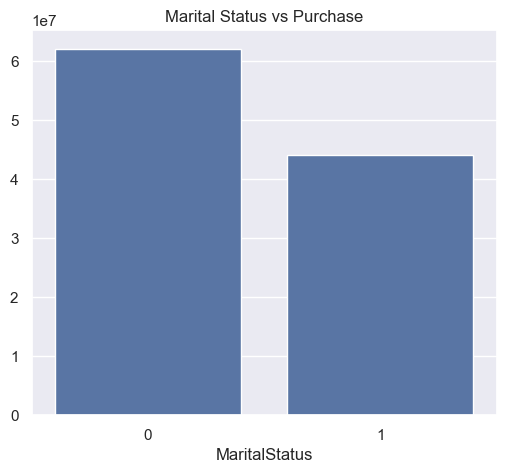

In [25]:
# Visualization 6 : Martial Status vs Purchase

plt.figure(figsize=(6,5))
marital_sales = df.groupby('MaritalStatus')['Amount'].sum()

sns.barplot(x=marital_sales.index, y=marital_sales.values)
plt.title("Marital Status vs Purchase")
plt.show()

# Insight 1 : Unmarried people spent more (₹6.20 Crore)
# Insight 2 : Married spent ₹4.40 Crore
# Conclusion : Unmarried customers spend more.

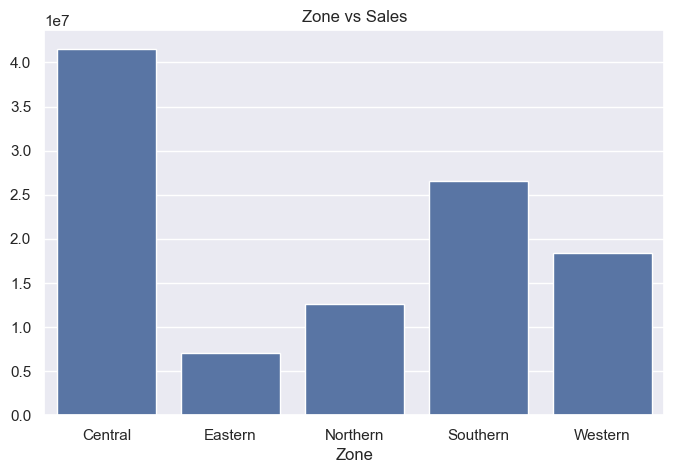

In [26]:
# Visualization 7 : Zone-wise Sales

plt.figure(figsize=(8,5))
zone_sales = df.groupby('Zone')['Amount'].sum()

sns.barplot(x=zone_sales.index, y=zone_sales.values)
plt.title("Zone vs Sales")
plt.show()

# Insight 1 : Central zone has highest sales
# Insight 2 : Followed by Southern zone
# Conclusion : Central India is biggest market.

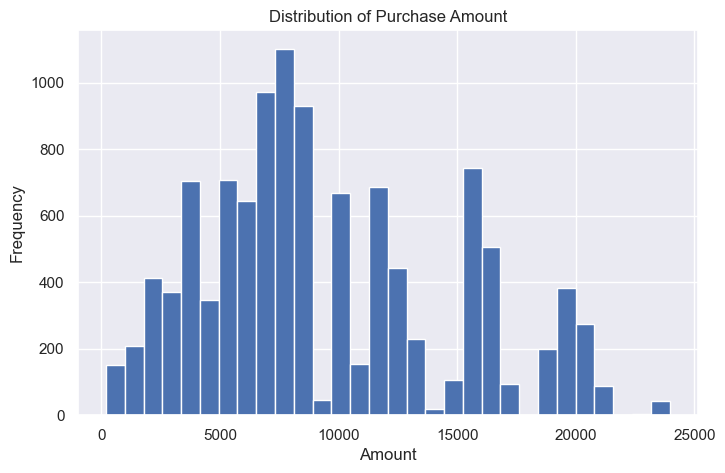

In [27]:
# Visualization 8 : Purchase Amount Distribution

plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=30)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Insight 1 : Most purchases are between ₹5000 and ₹15000
# Insight 2 : Few very high purchases exist
# Conclusion : Most customers are medium spenders.

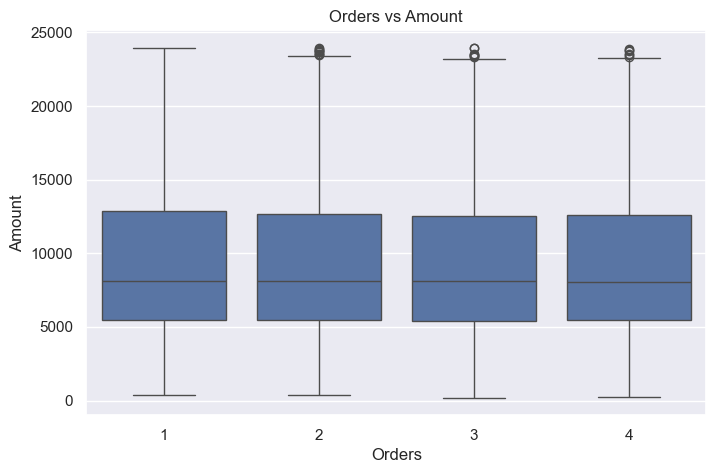

In [28]:
# Visualization 9 : Orders vs Purchase Amount

plt.figure(figsize=(8,5))
sns.boxplot(x='Orders', y='Amount', data=df)

plt.title("Orders vs Amount")
plt.show()

# Insight 1 : Purchase amount does not increase much with number of orders
# Insight 2 : Customers buy expensive items even in fewer orders
# Conclusion : Quality matters more than quantity.

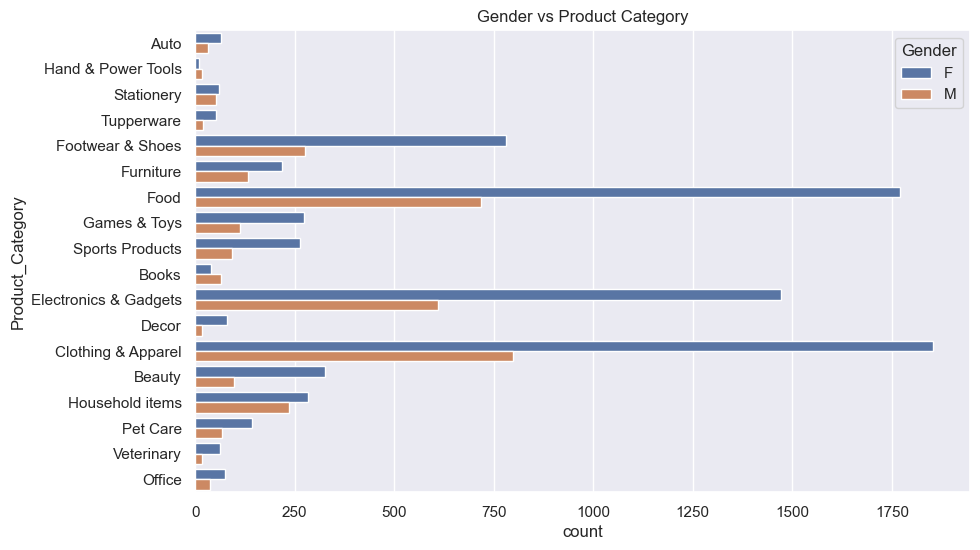

In [29]:
# Visualization 10 : Gender vs Product Category

plt.figure(figsize=(10,6))
sns.countplot(y='Product_Category', hue='Gender', data=df)

plt.title("Gender vs Product Category")
plt.show()

# Insight 1 : Females dominate most categories
# Insight 2 : Especially in Clothing and Food
# Conclusion : Females are dominant buyers in most product categories.